In [4]:
# Dependencias
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import imageio.v2 as imageio
import os

# Setup
if not os.path.exists('data'):
    os.makedirs('data')
if not os.path.exists('gifs'):
    os.makedirs('gifs')

IMAGE_PATH = 'data/snow_leopard.jpg'

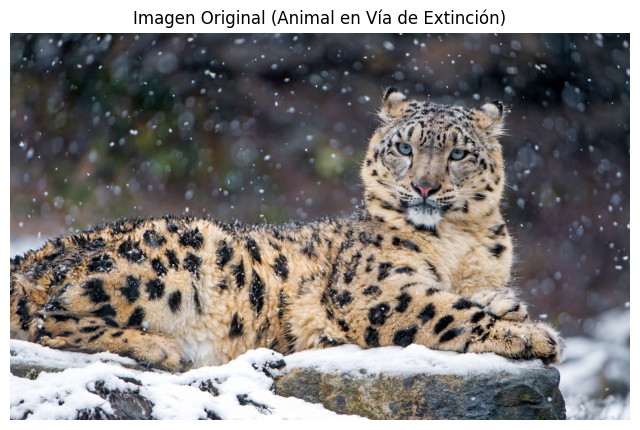

In [5]:
# Carga y Visualización de la Imagen Original (RGB)

try:
    # Cargar la imagen: cv2 lee en formato BGR por defecto
    img_bgr = cv2.imread(IMAGE_PATH)

    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {IMAGE_PATH}. ¡Verifica la ruta!")

    # Convertir a RGB para visualización correcta con Matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Mostrar imagen original
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title('Imagen Original (Animal en Vía de Extinción)')
    plt.axis('off')
    plt.show()

except FileNotFoundError as e:
    print(e)
    # Detener la ejecución si no se carga la imagen
    img_rgb = None
    img_bgr = None

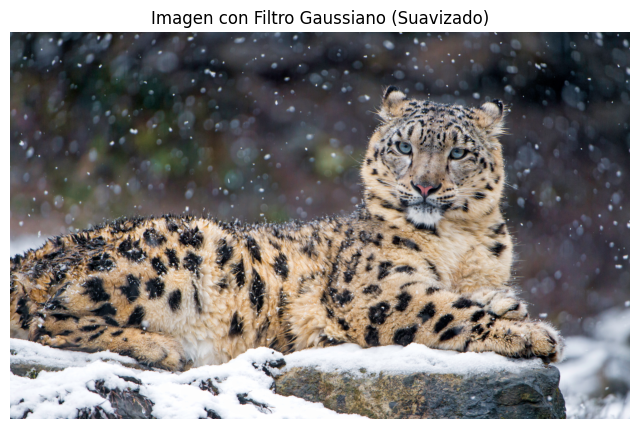

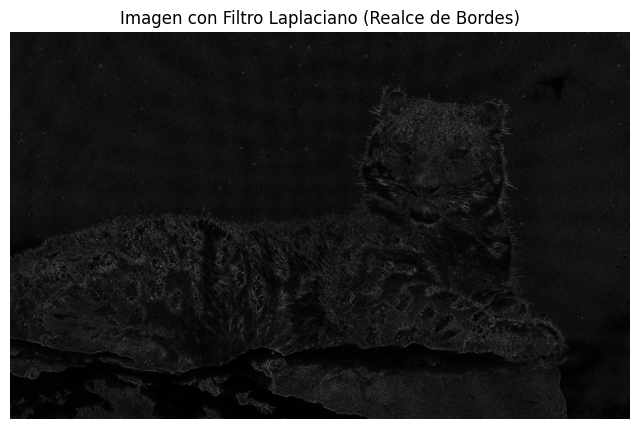

In [8]:
# Filtros Básicos

# Suavizado / Desenfoque (Filtro Gaussiano)

"""

El filtro Gaussiano reduce el ruido y los detalles finos de la imagen.
Visualmente, la imagen se ve 'desenfocada' o 'suavizada'.
Esto se logra promediando los valores de píxeles vecinos dentro de la ventana (kernel) aplicada.

"""

# Kernel de 5x5: Cuanto mayor sea el kernel, mayor el desenfoque
kernel_size_blur = (5, 5)
img_blur = cv2.GaussianBlur(img_bgr, kernel_size_blur, 0)
img_blur_rgb = cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_blur_rgb)
plt.title('Imagen con Filtro Gaussiano (Suavizado)')
plt.axis('off')
plt.show()


#-------------------------------------------------------------------------------------------------#

# Realce de Bordes (Filtro Laplaciano)

"""

El filtro Laplaciano es un operador de segunda derivada que detecta cambios rápidos en la intensidad de píxeles,
lo que corresponde a los bordes. El resultado es una imagen donde las áreas de color uniforme son oscuras
y solo los contornos y líneas de alto contraste son visibles y brillantes.

"""

# Convertir a escala de grises para realce de bordes (común para Laplaciano)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Aplicar el filtro Laplaciano
# El resultado se convierte a uint8 después de la operación para visualización
img_edges = cv2.Laplacian(img_gray, cv2.CV_64F)
img_edges_uint8 = cv2.convertScaleAbs(img_edges)

plt.figure(figsize=(8, 6))
plt.imshow(img_edges_uint8, cmap='gray')
plt.title('Imagen con Filtro Laplaciano (Realce de Bordes)')
plt.axis('off')
plt.show()

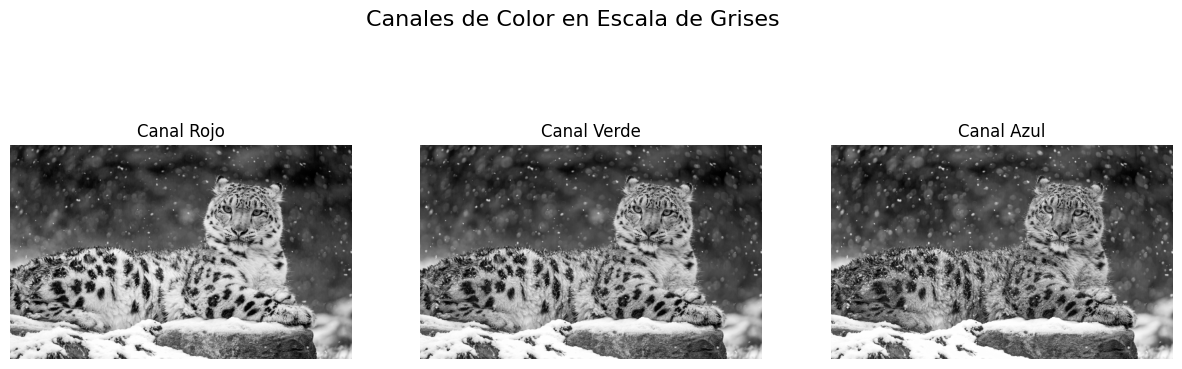

In [9]:
# 4. Visualización de Canales de Color (R, G, B)

"""

Canal Rojo (R): Las estructuras con alto contenido de rojo aparecerán más brillantes. Las áreas con poco rojo (p.ej., follaje verde intenso o sombras azules) aparecerán oscuras.

Canal Verde (G): Las estructuras con alto contenido de verde (p.ej., hojas, vegetación) aparecerán más brillantes.
El pelaje rojo o las rocas muy oscuras tenderán a ser oscuros.

Canal Azul (B): Las estructuras que reflejan mucha luz azul (p.ej., el cielo, agua, ciertas sombras frías)
aparecerán brillantes. Las estructuras rojas o marrones típicamente se verán muy oscuras.
En general, este canal suele ser el que tiene menos detalle de texturas.

La claridad u oscuridad de una estructura en un canal (mostrado en escala de grises) indica la INTENSIDAD de ese color primario
en la composición original de esa área. Un píxel blanco puro en el canal R significa que el color rojo
contribuye con el valor máximo (255) a la composición del color original en ese punto.

"""

# Separar los canales
B, G, R = cv2.split(img_bgr) # Recuerda, cv2 es BGR

channels = {'Rojo': R, 'Verde': G, 'Azul': B}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Canales de Color en Escala de Grises', fontsize=16)

for i, (name, channel) in enumerate(channels.items()):
    axes[i].imshow(channel, cmap='gray')
    axes[i].set_title(f'Canal {name}')
    axes[i].axis('off')

plt.show()


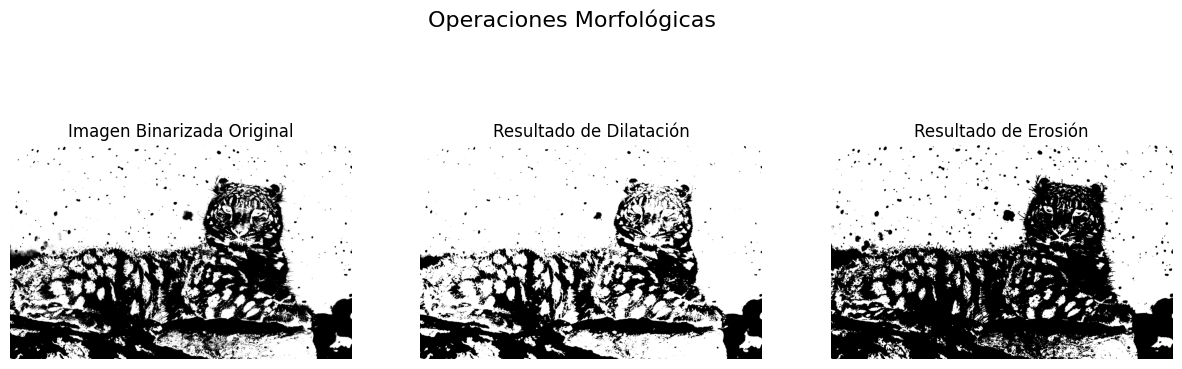

In [10]:
# Operaciones Morfológicas

"""

Efecto de la Dilatación:
La dilatación expande los límites de los objetos de primer plano (píxeles blancos).
En esta imagen binarizada, los objetos blancos se hacen más grandes, rellenando pequeños agujeros
y rompiendo espacios estrechos entre objetos. Visualmente, el objeto parece 'engordar'.

Efecto de la Erosión:
La erosión encoge los límites de los objetos de primer plano (píxeles blancos).
Los objetos pequeños y el ruido se eliminan, y los objetos más grandes se encogen.
Visualmente, el objeto parece 'adelgazar' y cualquier ruido periférico tiende a desaparecer.

"""

# Usar una imagen binarizada para operaciones morfológicas
# Binarización: Primero a gris, luego aplicar un umbral
ret, img_binary = cv2.threshold(img_gray, 120, 255, cv2.THRESH_BINARY_INV)

# Definir el kernel (elemento estructurante)
kernel = np.ones((5, 5), np.uint8)

# Dilatación
img_dilated = cv2.dilate(img_binary, kernel, iterations=1)

# Erosión
img_eroded = cv2.erode(img_binary, kernel, iterations=1)

# Visualización de Resultados Morfológicos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Operaciones Morfológicas', fontsize=16)

axes[0].imshow(img_binary, cmap='gray')
axes[0].set_title('Imagen Binarizada Original')
axes[0].axis('off')

axes[1].imshow(img_dilated, cmap='gray')
axes[1].set_title('Resultado de Dilatación')
axes[1].axis('off')

axes[2].imshow(img_eroded, cmap='gray')
axes[2].set_title('Resultado de Erosión')
axes[2].axis('off')

plt.show()

In [12]:
# Animación (Creación de GIF)


# Recopilación de Frames
# Convertir todas las imágenes a RGB (si no lo están) y guardar en una lista de arrays
frames = []

# Frame 1: Original
frames.append(img_rgb)

# Frame 2: Suavizado / Desenfoque
frames.append(img_blur_rgb)

# Frame 3: Realce de Bordes (lo convertimos a 3 canales para el GIF)
# Usaremos el resultado del Laplaciano en escala de grises, repetido en 3 canales
img_edges_rgb = cv2.cvtColor(img_edges_uint8, cv2.COLOR_GRAY2RGB)
frames.append(img_edges_rgb)

# Frame 4: Imagen Binarizada (convertida a 3 canales)
img_binary_rgb = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2RGB)
frames.append(img_binary_rgb)

# Frame 5: Dilatación (convertida a 3 canales)
img_dilated_rgb = cv2.cvtColor(img_dilated, cv2.COLOR_GRAY2RGB)
frames.append(img_dilated_rgb)

# Frame 6: Erosión (convertida a 3 canales)
img_eroded_rgb = cv2.cvtColor(img_eroded, cv2.COLOR_GRAY2RGB)
frames.append(img_eroded_rgb)

# Creación del GIF
gif_filename = 'gifs/procesamiento_secuencial.gif'

# Duplicar el primer frame para que la secuencia se vea mejor en bucle
frames_for_gif = frames + [frames[0]]

# Guardar usando imageio
imageio.mimsave(
    gif_filename,
    frames_for_gif,
    fps=1, # Velocidad: 1 frame por segundo
    loop=0 # Bucle infinito
 )

print(f"GIF generado y guardado en: {gif_filename}")

# Guardar imágenes en DATA
cv2.imwrite('data/img_original.png', img_bgr)
cv2.imwrite('data/filtro_suavizado.png', img_blur)
cv2.imwrite('data/filtro_bordes.png', img_edges_uint8)
cv2.imwrite('data/morfologia_binarizada.png', img_binary)
cv2.imwrite('data/morfologia_dilatacion.png', img_dilated)
cv2.imwrite('data/morfologia_erosion.png', img_eroded)

GIF generado y guardado en: gifs/procesamiento_secuencial.gif


True